# Basic tutorial: ``MapperGraph`` class

In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

# The main class for the Reeb Graph
from cereeberus import MapperGraph, ReebGraph

# Some built in example graphs
import cereeberus.data.ex_reebgraphs as ex_rg
import cereeberus.data.ex_mappergraphs as ex_mg

Mapper graphs are similar to Reeb graphs, except that: 
- The value of $f$  are *integers* in some range, `[n_low, ... , n_high]`.
- We store a `delta` so that we can equivalently think of the function values as being  `[delta * n_low, ... , delta * n_high]`.
- All edges have adjacent integers for function values. Equivalently, the inverse image of an integer is only vertices, no internal points of edges. This can be done by subdividing any edge as needed. 

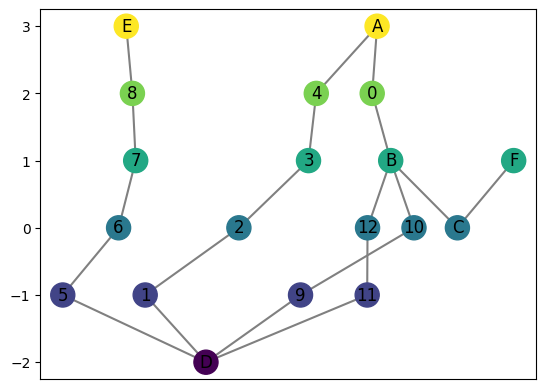

In [2]:
MG = MapperGraph( seed = 0, delta = 1)
MG.add_node('A', f_vertex = 3)
MG.add_node('B', f_vertex = 1)
MG.add_node('C', f_vertex = 0)
MG.add_node('D', f_vertex = -2)
MG.add_node('E', f_vertex = 3)
MG.add_node('F', f_vertex = 1)

MG.add_edge('A','B')
MG.add_edge('B','C')
MG.add_edge('A','D')
MG.add_edge('D','E')
MG.add_edge('D','B')
MG.add_edge('D','B')
MG.add_edge('C','F')

# These positions are the locations for the drawing
MG.set_pos_from_f(seed = 8)

MG.draw(cpx = 1)

We can convert a `ReebGraph` class instance into a  `MapperGraph` class instance. Note that this is **NOT** the same as computing the mapper graph of a Reeb graph treated as the input object. 

{0: 7, 1: 6, 2: 5, 3: 5, 4: 6, 5: 4, 6: 4, 7: 1}


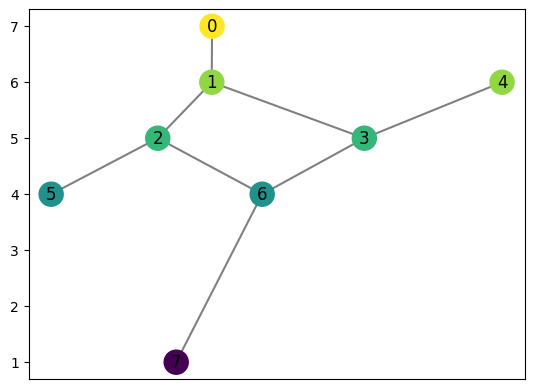

In [3]:
R = ex_rg.dancing_man(seed = 0)
R.draw()
print(R.f)

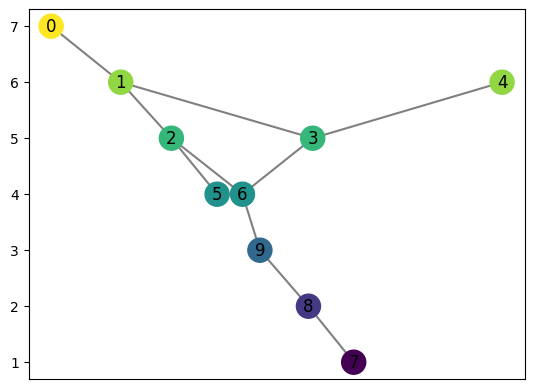

In [4]:
MG = R.to_mapper()
MG.draw()

However, if the Reeb graph has any vertices with a non-integer function value, no mapper graph instance can be created. 

## Smoothing of mapper graph 

We can construct the smoothing of a mapper graph in the same way that we can 

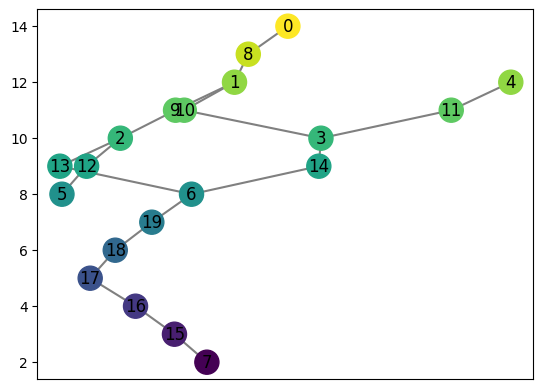

In [5]:
R = ex_rg.dancing_man()
R.f = {v: 2*R.f[v] for v in R.f.keys()}
M = R.to_mapper(delta = 1)
M.draw()

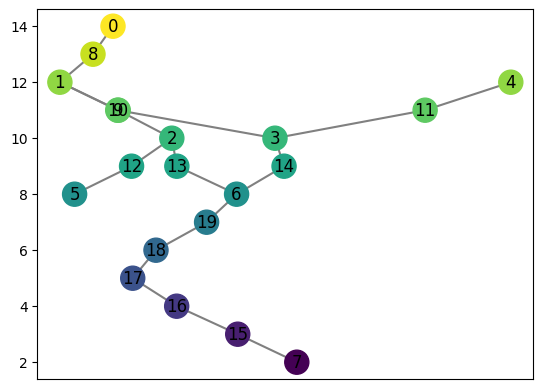

In [6]:
M_n = M.smoothing(n=1)
M.set_pos_from_f(seed = 42)
M.draw()

If we want this to return the map $(M,f) \to S_n(M,f)$ induced by inclusion, we can pass the `return_map = True` flag. 


In [7]:
M_n, map_induced = M.smoothing(n=1, return_map = True)

M_n.draw()
for v in list(map_induced.keys())[:5]:
    print(f"Original vertex {v} maps to new vertex {map_induced[v]}")

TypeError: MapperGraph.smoothing() got an unexpected keyword argument 'return_map'

We can also look at some matrices for the underlying graph. 

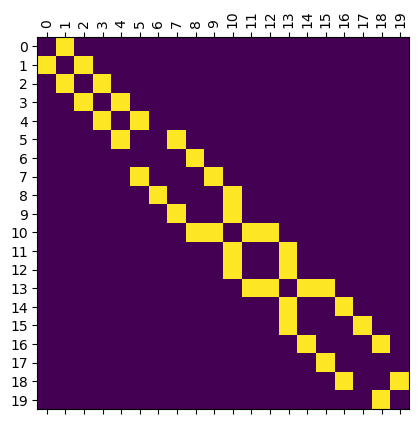

In [ ]:
# Returns the adjacency matrix 
A = M_n.adjacency_matrix()

# Plots the adjacency matrix
M_n.plot_adjacency_matrix()

We also have the boundary matrix, where $B[v,e] = 1$ if $v$ is an endpoint of $e$. Note that the edge labels `(u,v,k)` have a third entry in case of multiple edges between $u$ and $v$.

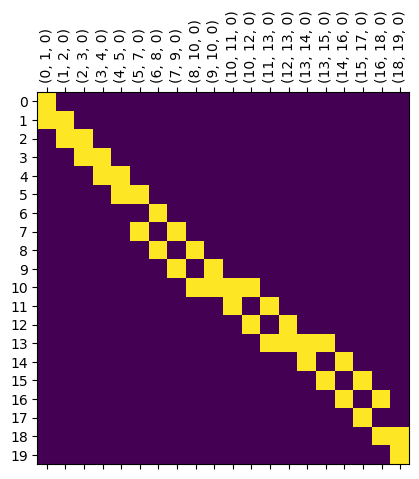

In [ ]:
# Returns the boundary matrix 
B = M_n.boundary_matrix()

# Plots the boundary matrix.
M_n.plot_boundary_matrix()

## Creating a Mapper Graph using runmapper

We may construct a mapper graph from a point cloud

In [8]:
from sklearn.datasets import make_circles

number_of_points = 500

data, labels = make_circles(n_samples=number_of_points, factor=0.4, noise=0.05, random_state=0)


val = 0
pointcloud = []
while val < number_of_points:
    pointcloud.append(data[val])
    val += 1

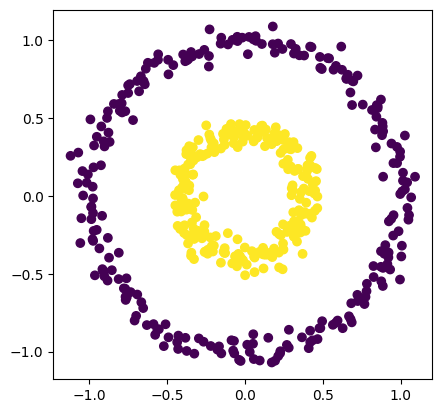

In [9]:
import matplotlib.pyplot as plt

plt.scatter(data[:, 0], data[:, 1], c=labels)
plt.axis('scaled');

We may compute the Mapper graph of this shape using runmapper

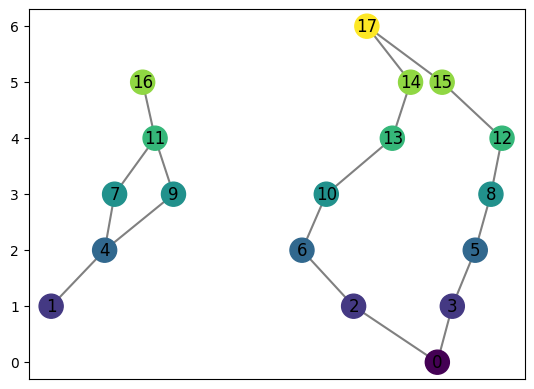

In [18]:
from cereeberus import MapperGraph
import sklearn

graph = MapperGraph()
graph = MapperGraph.runmapper(pointcloud, "y", MapperGraph.cover(min=-1, max=1, numcovers=7, percentoverlap=.4), sklearn.cluster.DBSCAN(min_samples=2,eps=0.3).fit) 
graph.draw()

The runmapper function takes 4 inputs:
- A point cloud
- A lens function
- A cover
- A clustering algorithm

Covers may be created using the Mappergraph.cover method

In [20]:
print(MapperGraph.cover(min=-1, max=1, numcovers=4, percentoverlap=.5))

[(-1.125, -0.375), (-0.625, 0.125), (-0.125, 0.625), (0.375, 1.125)]


Covering sets may go beyond the specified range if they have a nonzero percentage overlap with other covering sets.

Both covers and point clouds may be input manually

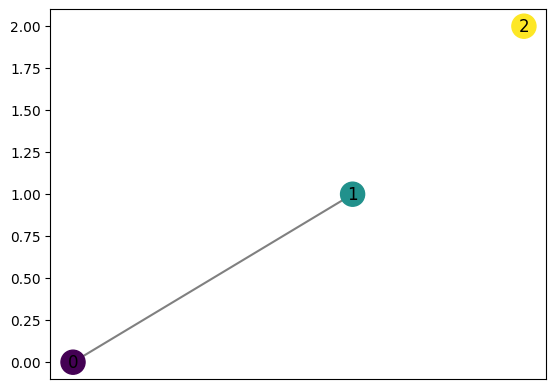

In [21]:
graph2 = MapperGraph.runmapper([(0.6, 0), (-0.1, 0.5)], "x", [(-1,0),(-0.5,0.5),(0,1)], "trivial")
graph2.draw()

runmapper allows for any sklearn clustering algorithm to be used as input. It will also work with the trvial clustering.

In [23]:
from sklearn.datasets import make_moons

number_of_points = 200

data, labels = make_moons(n_samples=number_of_points, noise=0.05, random_state=0)

val = 0
pointcloud = []
while val < number_of_points:
    pointcloud.append(data[val])
    val += 1

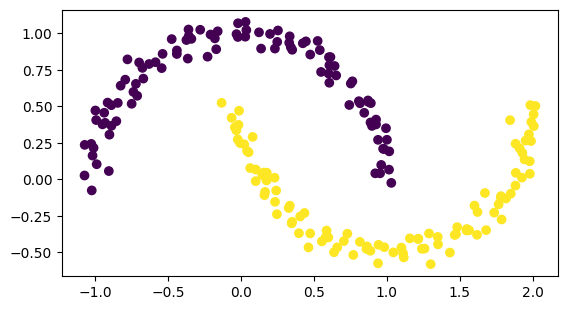

In [24]:
import matplotlib.pyplot as plt

plt.scatter(data[:, 0], data[:, 1], c=labels)
plt.axis('scaled');

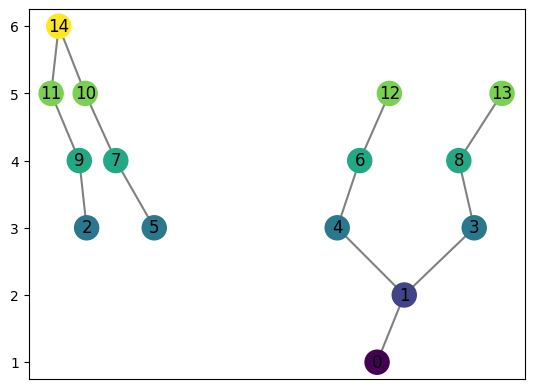

In [27]:
graph = MapperGraph()
graph = MapperGraph.runmapper(pointcloud, "y", MapperGraph.cover(min=-1, max=1, numcovers=7, percentoverlap=.4), sklearn.cluster.DBSCAN(min_samples=2,eps=0.3).fit) 
graph.draw()

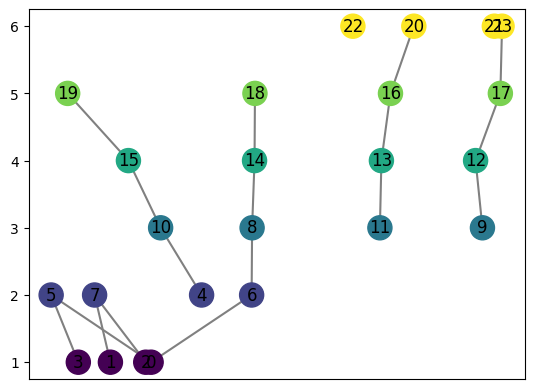

In [29]:
graph = MapperGraph()
graph = MapperGraph.runmapper(pointcloud, "y", MapperGraph.cover(min=-1, max=1, numcovers=7, percentoverlap=.4), sklearn.cluster.KMeans(n_clusters=4).fit) 
graph.draw()

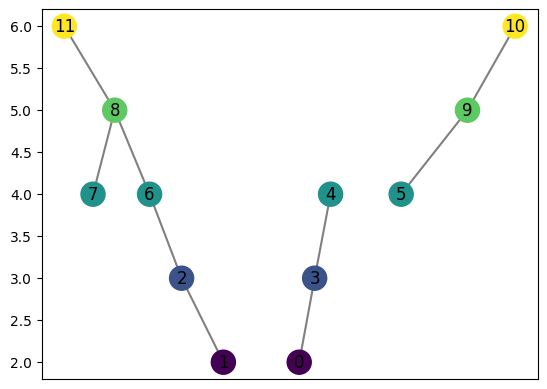

In [59]:
graph = MapperGraph()
graph = MapperGraph.runmapper(pointcloud, "y", MapperGraph.cover(min=-1, max=1, numcovers=7, percentoverlap=.4), sklearn.cluster.HDBSCAN(min_cluster_size=8).fit) 
graph.draw()

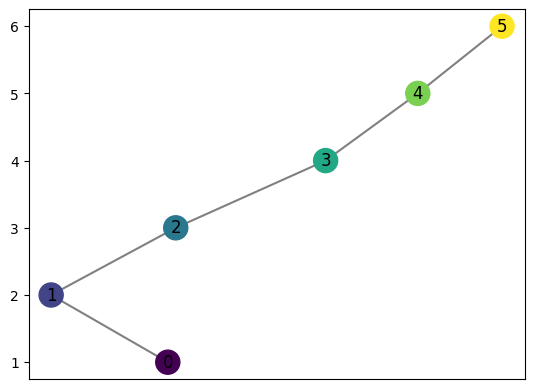

In [60]:
graph = MapperGraph()
graph = MapperGraph.runmapper(pointcloud, "y", MapperGraph.cover(min=-1, max=1, numcovers=7, percentoverlap=.4), "trivial") 
graph.draw()

runmapper orders the coveringsets it takes as input, preserving the location of each for better computing the distances between graphs

Notice where the labels for the graph start

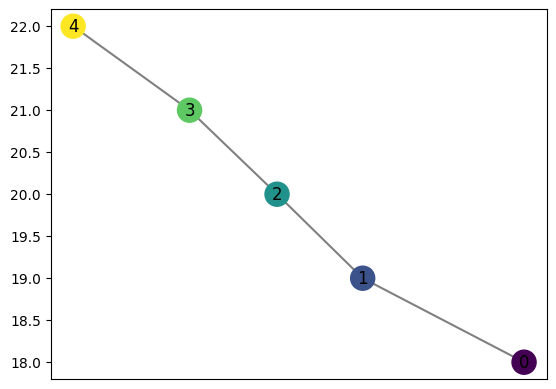

In [61]:
graph = MapperGraph()
graph = MapperGraph.runmapper(pointcloud, "y", MapperGraph.cover(min=-10, max=10, numcovers=40, percentoverlap=.4), "trivial") 
graph.draw()

runmapper accepts any function recognizable by numpy as input

In [111]:
from sklearn.datasets import make_swiss_roll
number_of_points = 300

data, labels = make_swiss_roll(n_samples=number_of_points, noise=0.1, random_state=0)

val = 0
pointcloud = []
while val < number_of_points:
    pointcloud.append((data[val][0],data[val][2]))
    val += 1

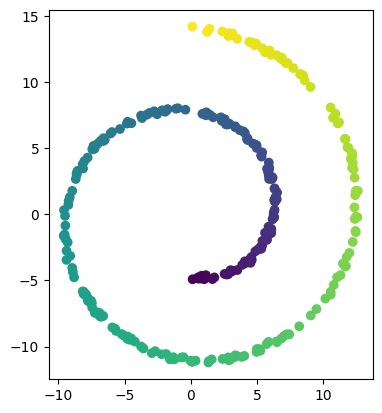

In [112]:
import matplotlib.pyplot as plt

plt.scatter(data[:, 0], data[:, 2], c=labels)
plt.axis('scaled');

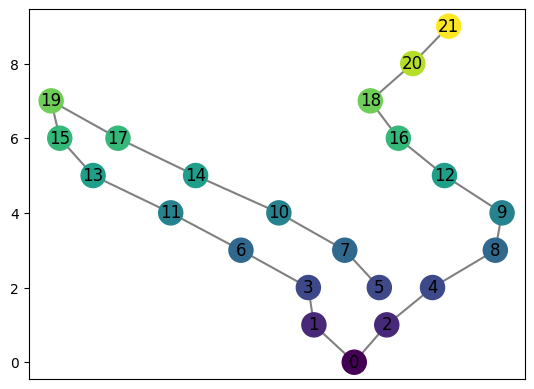

In [130]:
graph = MapperGraph()
graph = MapperGraph.runmapper(pointcloud, "y", MapperGraph.cover(min=-12, max=15, numcovers=10, percentoverlap=.4), sklearn.cluster.DBSCAN(min_samples=2,eps=3).fit) 
graph.draw()

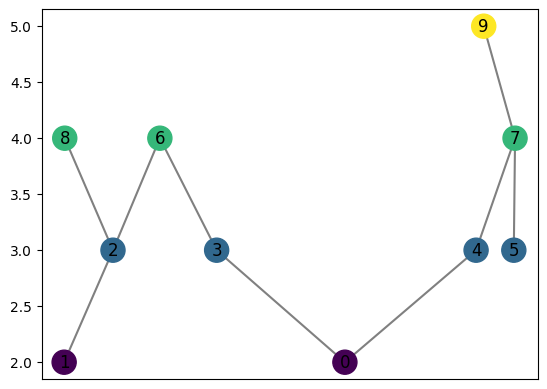

In [160]:
graph = MapperGraph()
graph = MapperGraph.runmapper(pointcloud, "x*y", MapperGraph.cover(min=-200, max=200, numcovers=7, percentoverlap=.4), sklearn.cluster.DBSCAN(min_samples=2,eps=3).fit) 
graph.draw()

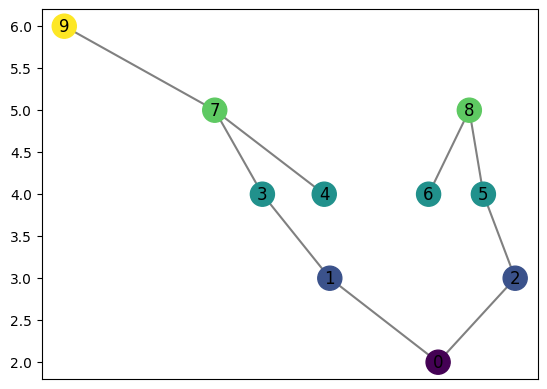

In [162]:
graph = MapperGraph()
graph = MapperGraph.runmapper(pointcloud, "sqrt(x+15)", MapperGraph.cover(min=0, max=6, numcovers=7, percentoverlap=.4), sklearn.cluster.DBSCAN(min_samples=2,eps=3).fit) 
graph.draw()

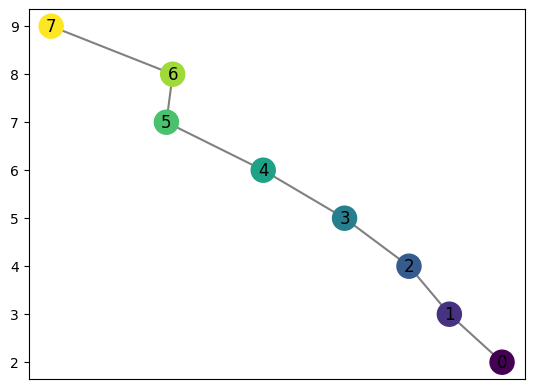

In [174]:
graph = MapperGraph()
graph = MapperGraph.runmapper(pointcloud, "sqrt((x*x)+(y*y))", MapperGraph.cover(min=0, max=15, numcovers=10, percentoverlap=.4), sklearn.cluster.DBSCAN(min_samples=2,eps=3).fit) 
graph.draw()